<a href="https://colab.research.google.com/github/shravani-j/enterprise-goals/blob/main/phishing_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv('/content/phishing.csv')
#intial data understanding
df.head()
df.shape
df.info()
df.describe()

#data preprocessing
#checking missing values
df.isnull().sum()

#check duplicate records
df.duplicated().sum()

#remove duplicates
df= df.drop_duplicates()








<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11054 entries, 0 to 11053
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Index                11054 non-null  int64
 1   UsingIP              11054 non-null  int64
 2   LongURL              11054 non-null  int64
 3   ShortURL             11054 non-null  int64
 4   Symbol@              11054 non-null  int64
 5   Redirecting//        11054 non-null  int64
 6   PrefixSuffix-        11054 non-null  int64
 7   SubDomains           11054 non-null  int64
 8   HTTPS                11054 non-null  int64
 9   DomainRegLen         11054 non-null  int64
 10  Favicon              11054 non-null  int64
 11  NonStdPort           11054 non-null  int64
 12  HTTPSDomainURL       11054 non-null  int64
 13  RequestURL           11054 non-null  int64
 14  AnchorURL            11054 non-null  int64
 15  LinksInScriptTags    11054 non-null  int64
 16  ServerFormHandler    1

The dataset was already well-structured with no null values or datatype inconsistencies, reducing preprocessing complexity.

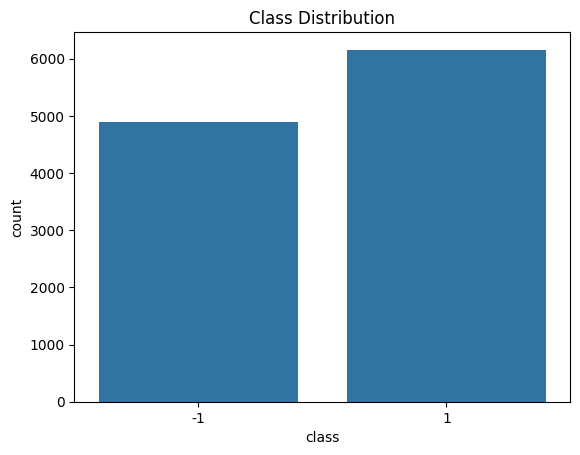

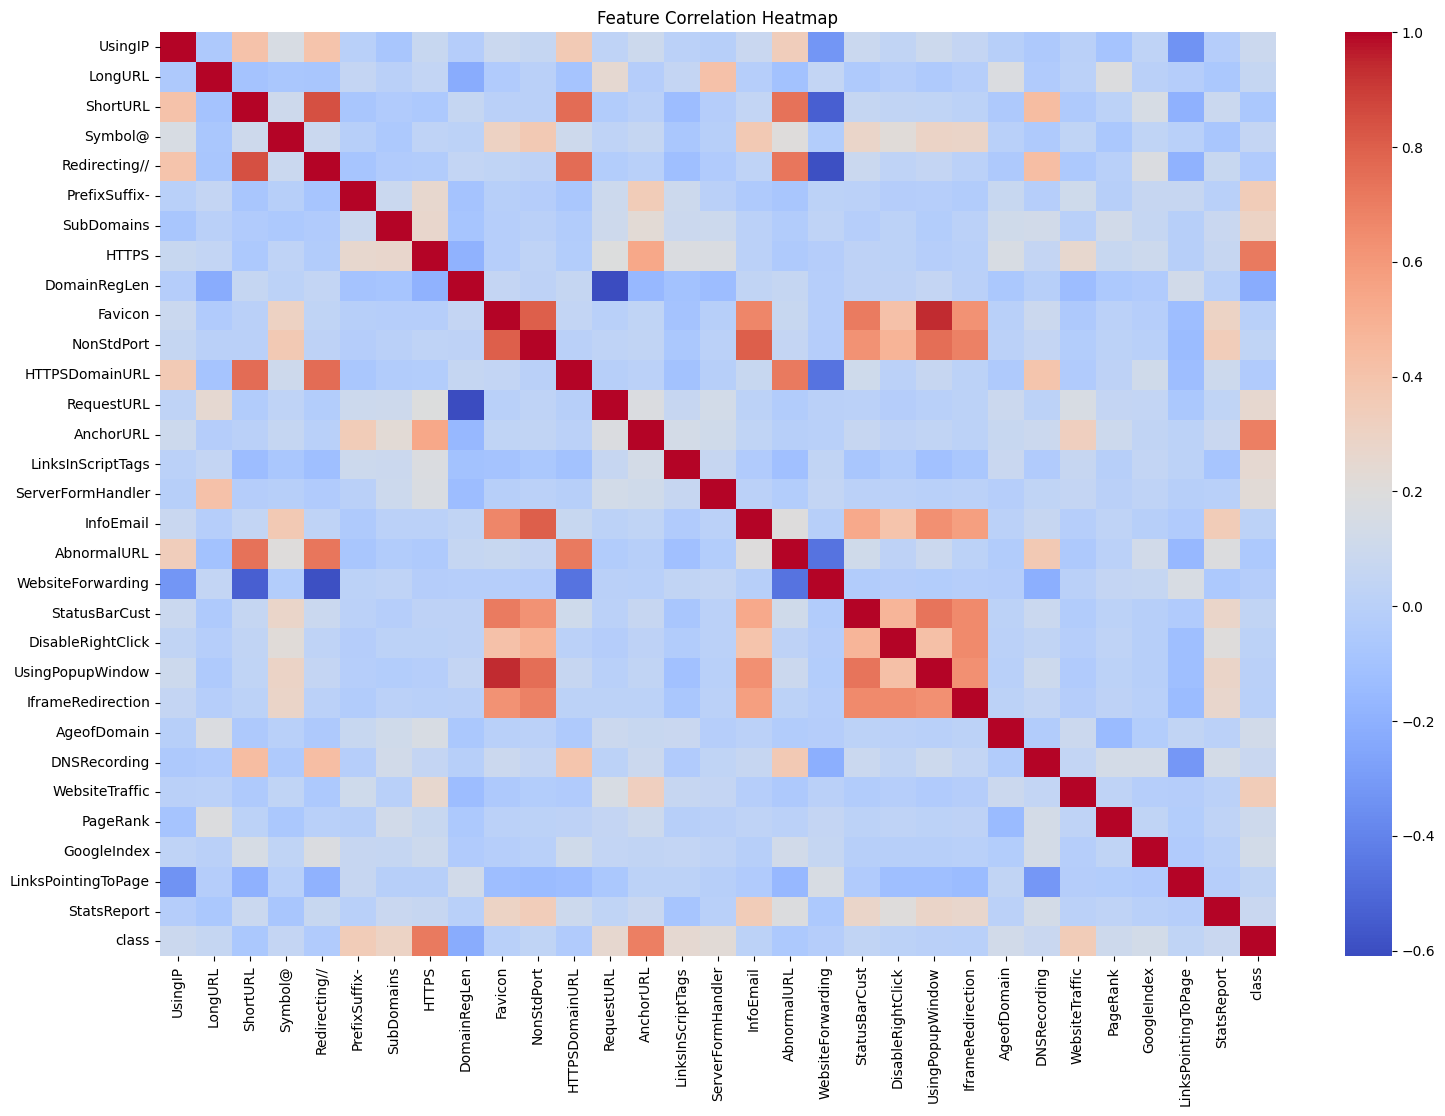

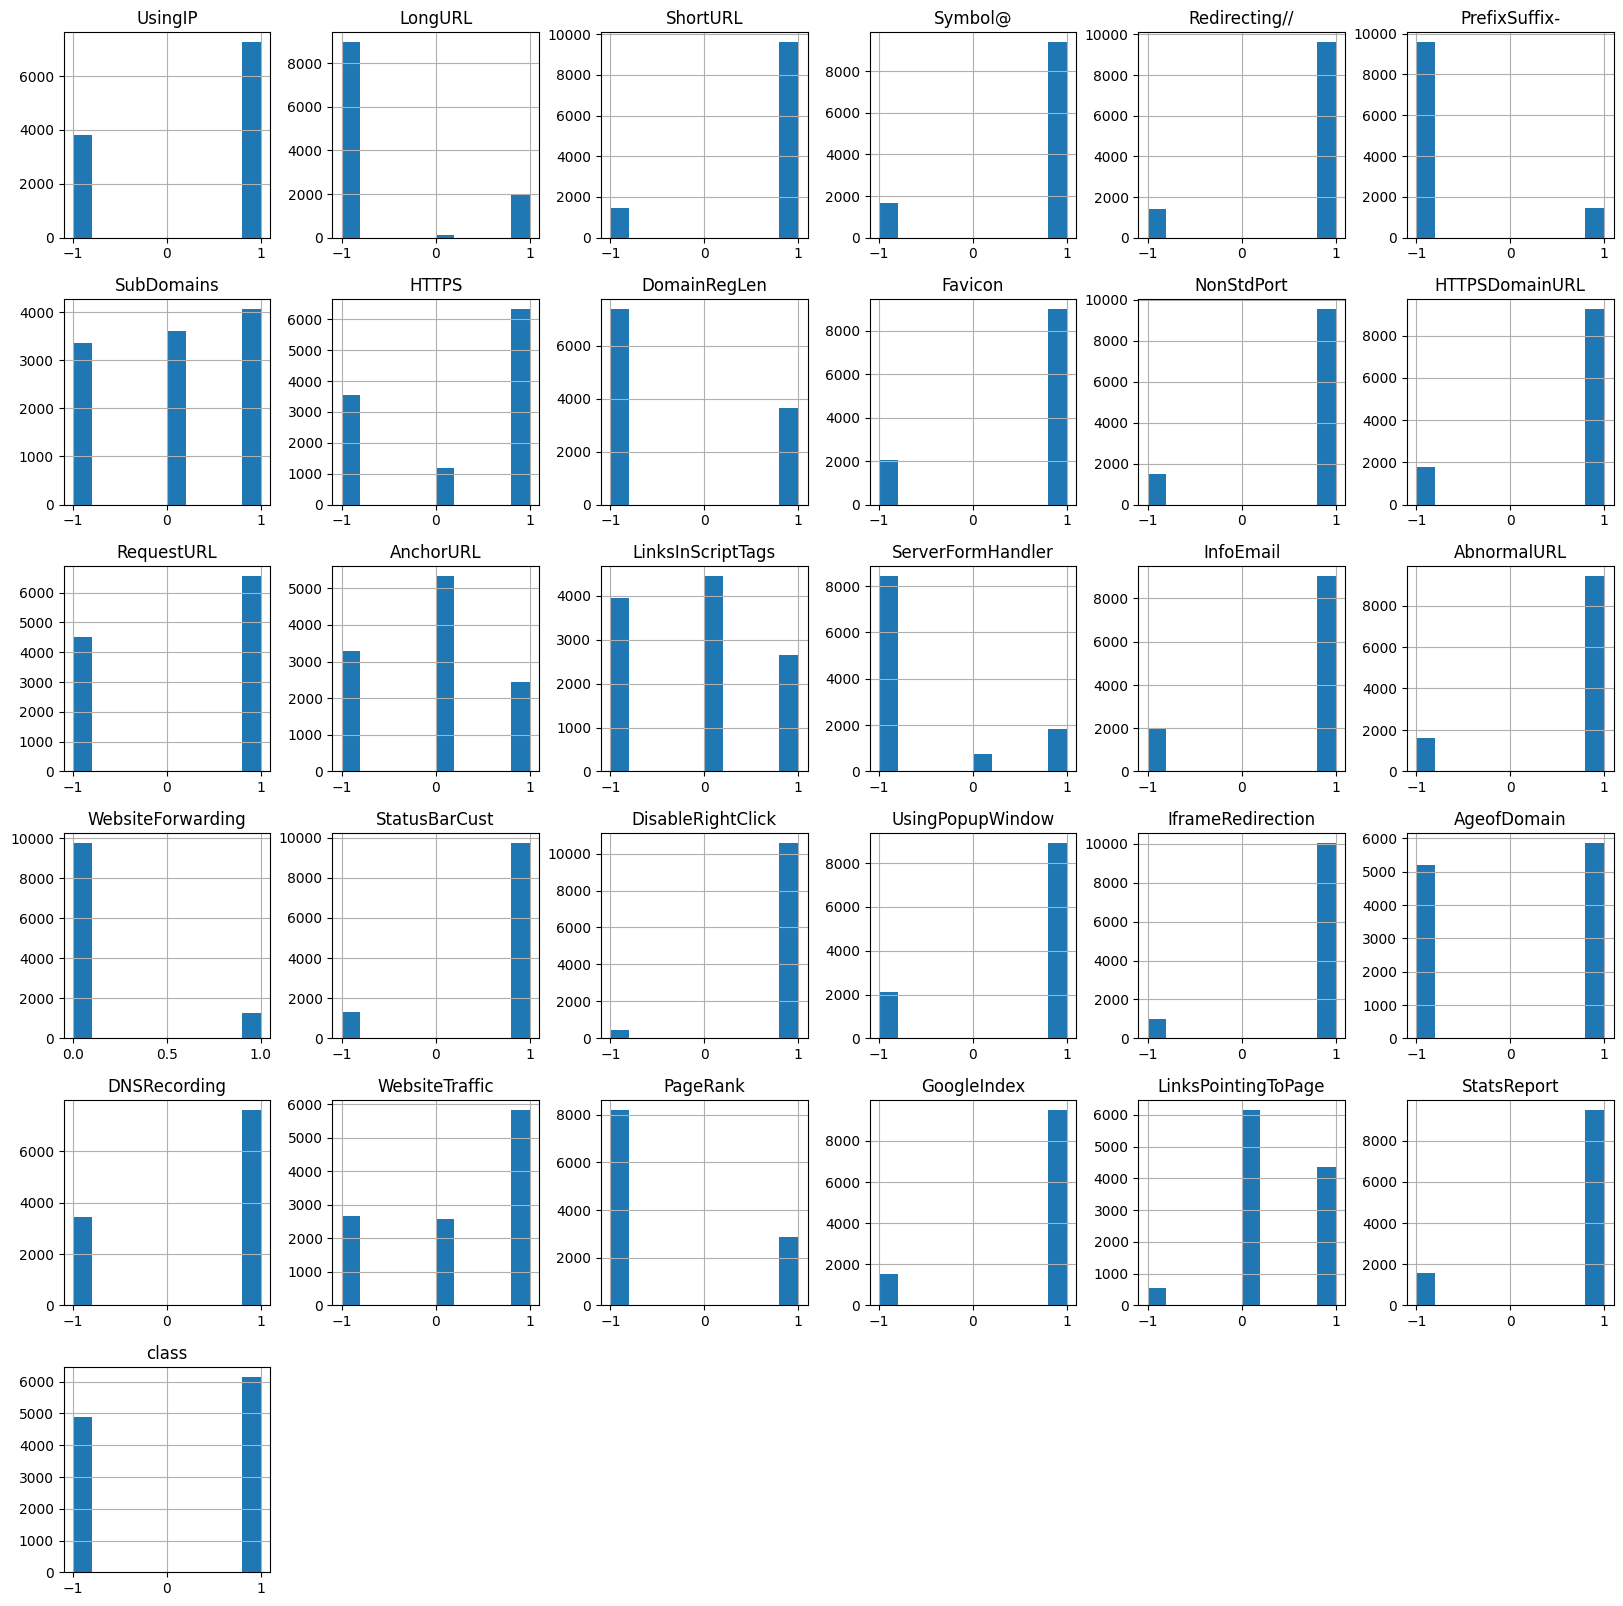

In [35]:
#EDA- exploratory data analysis
sns.countplot(x='class', data= df) #insight: check whether data is balanced or imbalanced
plt.title("Class Distribution")
plt.show()

Most features are categorical and highly skewed toward binary values (-1 and 1), indicating rule-based website characteristics.

Certain phishing indicators tend to appear together, suggesting coordinated malicious behavior patterns.

In [ ]:
df = df.drop('Index', axis=1)

#correlation heatmap
plt.figure(figsize=(18,12)) #insight: identifying highly correlated phishing indicators
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

Certain phishing indicators tend to appear together, suggesting coordinated malicious behavior patterns.

In [ ]:
#distribition of features
df.hist(figsize=(20,20))
plt.show()

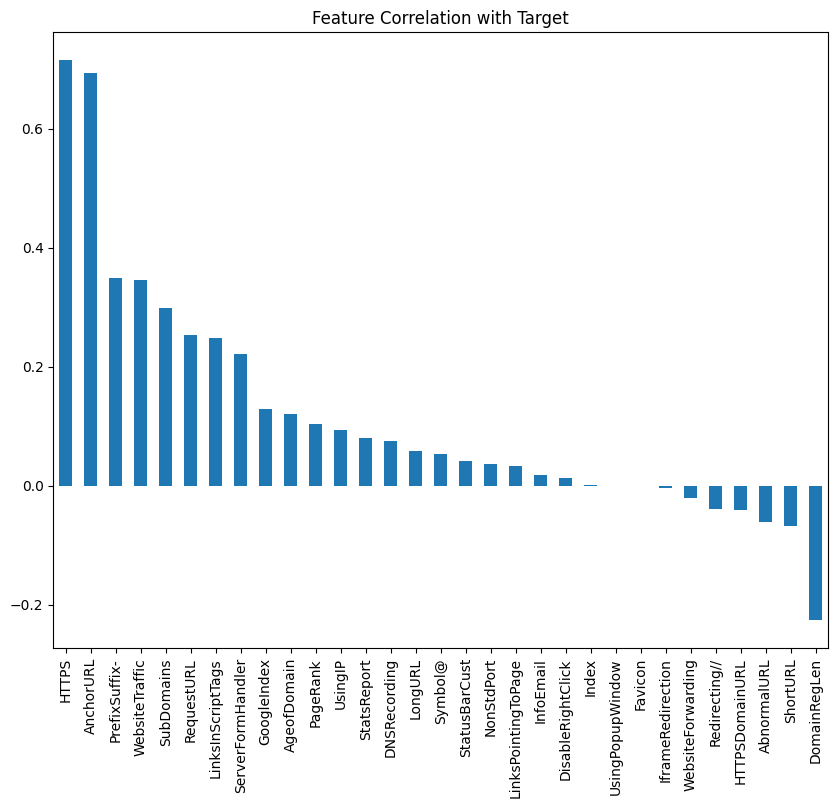

In [32]:
#visualization
#top features correlated with phishing
corr = df.corr()['class'].sort_values(ascending=False)

plt.figure(figsize=(10,8))
corr.drop('class').plot(kind='bar')
plt.title("Feature Correlation with Target")
plt.show()

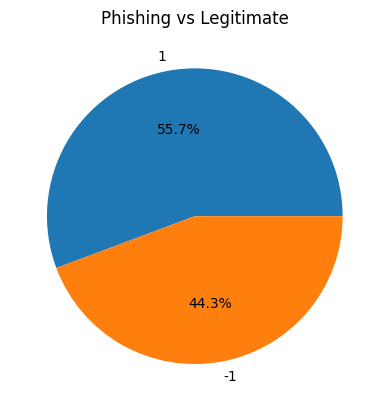

In [33]:
#pie chart of classes
df['class'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Phishing vs Legitimate")
plt.ylabel('')
plt.show()




The dataset is relatively balanced, with legitimate websites slightly outnumbering phishing websites. This balance makes the analysis unbiased toward either class.

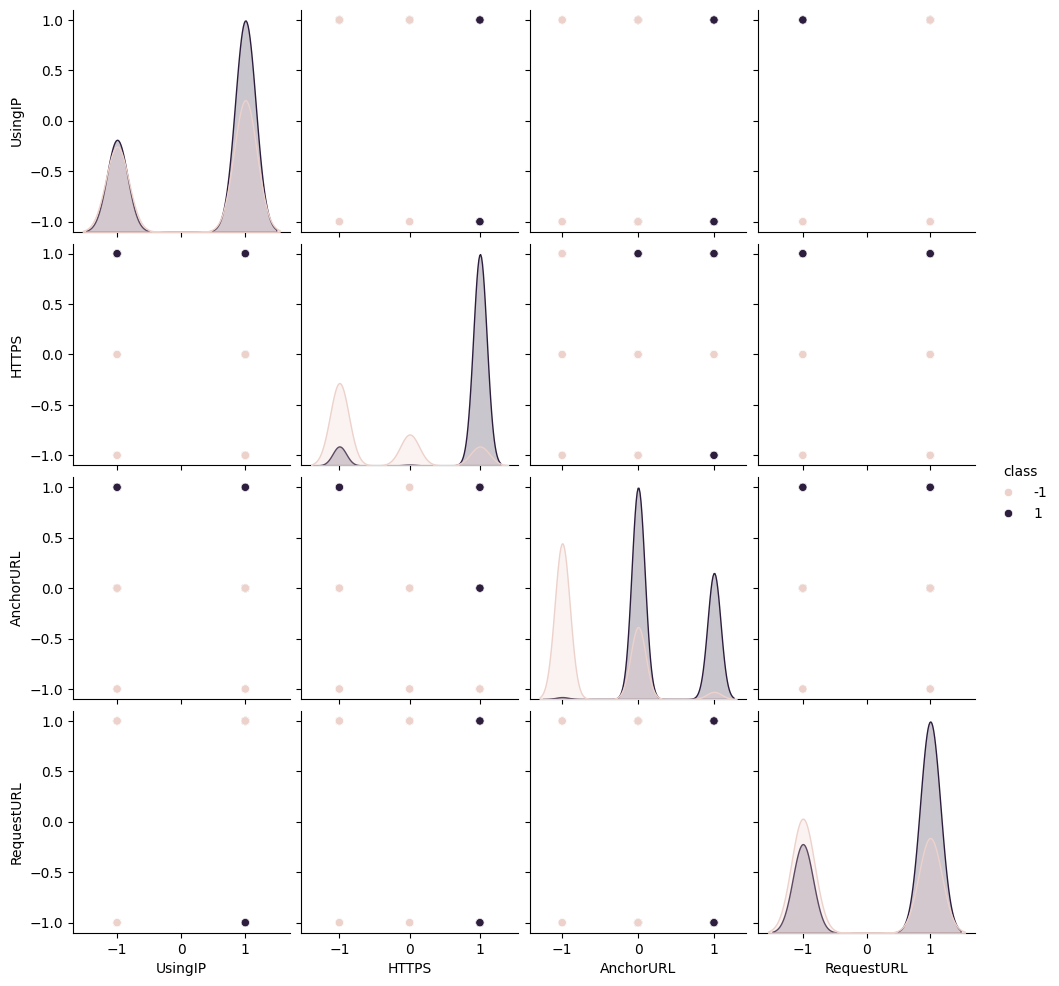

In [34]:
#pairplot of selected features
selected = [
    'UsingIP',
    'HTTPS',
    'AnchorURL',
    'RequestURL',
    'class'
]

sns.pairplot(df[selected], hue='class')
plt.show()



1.   Websites with proper HTTPS usage tend to be more legitimate.
2.   Shortened URLs appear more frequently in phishing websites because attackers use them to hide malicious destinations.
3. Abnormal URL structures strongly indicate phishing behavior.
4. Domains with short registration lengths are more likely to be phishing sites.




This project analyzed phishing website characteristics using exploratory data analysis techniques. Features related to URL structure, HTTPS usage, redirects, shortened URLs, and abnormal domain behavior showed strong relationships with phishing activity. The analysis revealed that phishing websites commonly exploit misleading URL patterns and suspicious web behaviors to deceive users. Visualization and correlation analysis helped identify the most influential indicators of malicious websites.